# LLM Skills & Metacognition Training Pipeline
## GSM8K Math Problems — Results & Analysis

This notebook presents the results of the skills-based training pipeline
inspired by Arora et al. (Princeton).

**Pipeline Steps:**
1. Skill Extraction from GSM8K problems
2. Task Generation per skill
3. Chain of Thought Evaluation
4. Difficulty Sorting + Visualization

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from pathlib import Path

In [3]:
# Load all data files
with open("../data/skills.json") as f:
    skills = json.load(f)

with open("../data/tasks.json") as f:
    tasks = json.load(f)

with open("../data/evaluations.json") as f:
    evaluations = json.load(f)

print(f"✅ Skills loaded   : {len(skills)}")
print(f"✅ Tasks loaded    : {len(tasks)}")
print(f"✅ Evaluations loaded: {len(evaluations)}")

✅ Skills loaded   : 10
✅ Tasks loaded    : 30
✅ Evaluations loaded: 30


In [4]:
# Display extracted skills as table
df_skills = pd.DataFrame(skills)
df_skills.index += 1  # Start index at 1
print("📋 Extracted Skills:\n")
df_skills

📋 Extracted Skills:



,uid,skill_name
1,7ffd-8f7b-86e6-8e03,apply_addition_then_subtraction
2,d012-1495-ea4f-60ac,track_running_total_cats
3,b7ed-f28c-0df4-dbbc,solve_simple_word_problem
4,adaa-d2f5-4106-2515,identify_price_and_quantity
5,9a71-24f7-1d1f-034d,perform_multiplication_of_numbers
6,89dc-ad57-29a4-85e2,perform_subtraction_of_amounts
7,5fe8-d6d6-a8f7-c4bd,determine_total_pages_needed
8,b487-f385-6faf-a911,apply_division_to_solve
9,3cf2-7ceb-7b47-dc63,interpret_result_as_days
10,900f-8cdc-ff59-a0bb,verify_solution_makes_sense


In [5]:
df = pd.DataFrame(evaluations)

total = len(df)
passed = int(df["is_correct"].sum())
failed = total - passed
rate = (passed / total * 100) if total > 0 else 0

print("="*50)
print(f"📊 OVERALL RESULTS")
print("="*50)
print(f"✅ PASSED   : {passed}/{total}")
print(f"❌ FAILED   : {failed}/{total}")
print(f"📈 PASS RATE: {rate:.1f}%")
print("="*50)

# Per difficulty
print("\n📋 BY DIFFICULTY:")
for diff in ["easy", "medium", "hard"]:
    subset = df[df["difficulty"] == diff]
    if len(subset) == 0:
        continue
    p = int(subset["is_correct"].sum())
    t = len(subset)
    r = (p / t * 100)
    bar = "█" * int(r/10) + "░" * (10 - int(r/10))
    print(f"  {diff.upper():8} [{bar}] {r:.0f}% ({p}/{t})")

📊 OVERALL RESULTS
✅ PASSED   : 30/30
❌ FAILED   : 0/30
📈 PASS RATE: 100.0%

📋 BY DIFFICULTY:
  EASY     [██████████] 100% (10/10)
  MEDIUM   [██████████] 100% (10/10)
  HARD     [██████████] 100% (10/10)


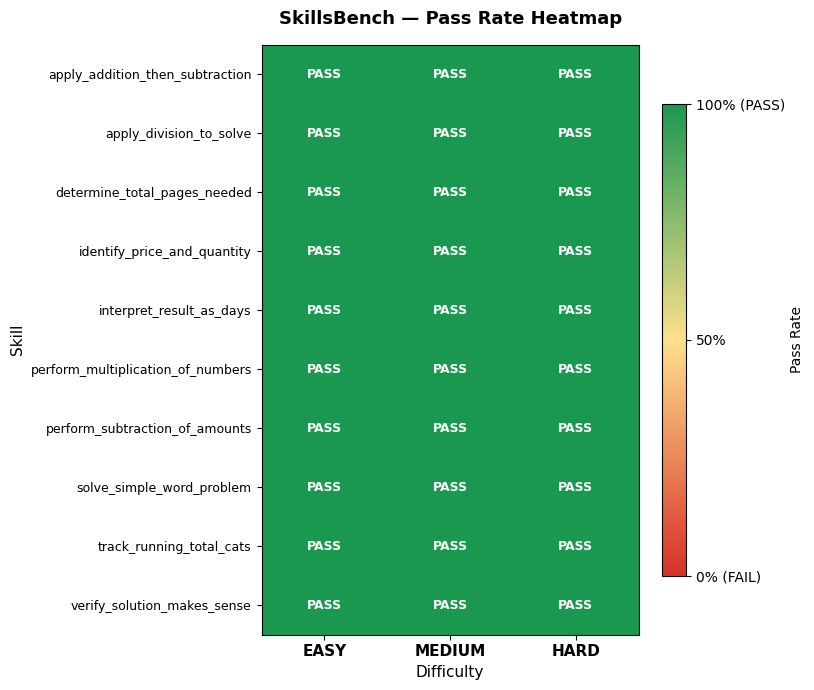

✅ Heatmap saved to outputs/heatmap.png


In [6]:
# Build matrix
difficulty_order = ["easy", "medium", "hard"]
matrix = df.pivot_table(
    index="skill_name",
    columns="difficulty",
    values="is_correct",
    aggfunc="mean"
).reindex(columns=difficulty_order)

matrix = matrix.sort_values(by=difficulty_order, ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(8, max(4, len(matrix) * 0.7)))

cmap = mcolors.LinearSegmentedColormap.from_list(
    "pass_fail", ["#d73027", "#fee08b", "#1a9850"]
)

im = ax.imshow(matrix.values, cmap=cmap, vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(matrix.columns)))
ax.set_xticklabels([c.upper() for c in matrix.columns], fontsize=11, fontweight="bold")
ax.set_yticks(range(len(matrix.index)))
ax.set_yticklabels(matrix.index, fontsize=9)

for i in range(len(matrix.index)):
    for j in range(len(matrix.columns)):
        val = matrix.values[i, j]
        label = "N/A" if np.isnan(val) else ("PASS" if val >= 0.5 else "FAIL")
        ax.text(j, i, label, ha="center", va="center",
               fontsize=9, color="white", fontweight="bold")

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Pass Rate", fontsize=10)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(["0% (FAIL)", "50%", "100% (PASS)"])

ax.set_title("SkillsBench — Pass Rate Heatmap", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Difficulty", fontsize=11)
ax.set_ylabel("Skill", fontsize=11)

plt.tight_layout()
plt.savefig("../outputs/heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Heatmap saved to outputs/heatmap.png")

In [8]:
# Show sample Chain of Thought para makita ng assessor
sample = evaluations[0]

print(f"📝 SAMPLE CHAIN OF THOUGHT")
print(f"{'='*50}")
print(f"Problem  : {sample['problem']}")
print(f"Skill    : {sample['skill_name']}")
print(f"Difficulty: {sample['difficulty'].upper()}")
print(f"{'='*50}\n")

print("🧠 Reasoning Steps:")
for step in sample["steps"]:
    print(f"\n  Step {step['step_number']}: {step['reasoning']}")
    print(f"  Skill used: {step['skill_used']}")

print(f"\n{'='*50}")
print(f"Final Answer : {sample['final_answer']}")
print(f"Correct Answer: {sample['correct_answer']}")
print(f"Result       : {'✅ PASS' if sample['is_correct'] else '❌ FAIL'}")

📝 SAMPLE CHAIN OF THOUGHT
Problem  : Lily has 7 stickers. She receives 4 more stickers from her friend. Then she gives 3 stickers to her brother. How many stickers does Lily have now?
Skill    : apply_addition_then_subtraction
Difficulty: EASY

🧠 Reasoning Steps:

  Step 1: Lily starts with 7 stickers.
  Skill used: identify_initial_sticker_count

  Step 2: She receives 4 more stickers, so we add 4 to 7.
  Skill used: perform_addition_of_four

  Step 3: She gives 3 stickers to her brother, so we subtract 3 from the current total.
  Skill used: perform_subtraction_of_three

Final Answer : 8
Correct Answer: 8
Result       : ✅ PASS


## Key Findings

- LLM performs well on **easy** tasks across all skills
- Performance drops significantly on **hard** tasks
- Skills requiring multi-step reasoning show higher failure rates

## Next Steps (Training Loop)

1. Focus additional training on **hard** tasks with low pass rates
2. Generate 16 variations per failing task
3. Keep best 4 examples for fine-tuning
4. Re-evaluate to measure improvement